# Dimension scaling relationship: p, m, and d

This exploratory study asks what the Recursive Sketch target dimension `d` should scale with. We distinguish three widths:

- `p`: the original dataset feature count seen by the initial projection;
- `m`: the uncompressed visited-node/path feature width of the fitted random forest, i.e. the sum of the node counts of its trees;
- `d`: the target width of each Recursive Sketch projection block.

The central comparison is whether competitiveness with the raw random-forest baseline is more stable as a function of `d/p`, `d/m`, absolute `d`, or none of these. We vary controlled synthetic input widths, include the scikit-learn breast-cancer dataset as a real reference, vary `n_estimators` over 100 and 500 trees, and sweep through dimensions below and above `p`, including `d=8192`.

This is exploratory evidence, not a proof. The default grid uses the heavier 100- and 500-tree forests but remains intentionally bounded. Set `FORESTSKETCH_QUICK=1` for a smaller smoke run.

In [1]:
import os
import sys
import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.datasets import load_breast_cancer, make_classification
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.random_projection import DataDimensionalityWarning

notebooks_dir = Path.cwd() / "notebooks"
if not (notebooks_dir / "_hypothesis_utils.py").exists():
    notebooks_dir = Path.cwd()
sys.path.insert(0, str(notebooks_dir))

from recursivesketch import RecursiveSketchClassifier
from _hypothesis_utils import serialized_size_mb

warnings.filterwarnings(
    "ignore",
    category=DataDimensionalityWarning,
    message="The number of components is higher than the number of features.*",
)

QUICK = os.environ.get("FORESTSKETCH_QUICK", "0").lower() in {"1", "true", "yes"}
print(f"quick mode: {QUICK}")

quick mode: False


In [2]:
# The full run is 4 datasets x 2 forest sizes (100 and 500 trees) x 6 dimensions x 2 paired seeds.
# Sparse path projections keep the d=8192 stress point bounded while retaining
# the same Recursive Sketch estimator and making the projection choice explicit.
DIMENSIONS = [8, 32, 128, 512, 2048, 8192]
DATASET_NAMES = ["synthetic_p12", "synthetic_p48", "synthetic_p120", "breast_cancer_p30"]
FOREST_SIZES = [100, 500]
SEEDS = [0, 1]
N_SAMPLES = 900

if QUICK:
    DATASET_NAMES = DATASET_NAMES[:2]
    FOREST_SIZES = [8, 16]
    DIMENSIONS = [8, 128, 8192]
    SEEDS = [0]
    N_SAMPLES = 600

def make_dataset(name, seed):
    if name.startswith("synthetic_"):
        p = int(name.removeprefix("synthetic_p"))
        informative = min(max(2, p // 6), p - 1)
        redundant = min(max(0, p // 5), p - informative)
        X, y = make_classification(
            n_samples=N_SAMPLES,
            n_features=p,
            n_informative=informative,
            n_redundant=redundant,
            n_repeated=0,
            n_classes=2,
            class_sep=0.8,
            flip_y=0.03,
            random_state=seed,
        )
    else:
        data = load_breast_cancer()
        X, y = data.data, data.target
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.30, stratify=y, random_state=seed + 1000
    )
    return X_train, X_test, y_train, y_test

def forest(seed, n_estimators):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=8,
        min_samples_leaf=1,
        n_jobs=-1,
        random_state=seed,
    )

def downstream(seed):
    return make_pipeline(
        StandardScaler(with_mean=False),
        LogisticRegression(max_iter=1000, solver="liblinear", random_state=seed),
    )

def representation_mb(value):
    if hasattr(value, "data") and hasattr(value, "indices") and hasattr(value, "indptr"):
        return (value.data.nbytes + value.indices.nbytes + value.indptr.nbytes) / 2**20
    return np.asarray(value).nbytes / 2**20

def path_width(fitted_sketch):
    return int(sum(encoder.n_output_features_ for encoder in fitted_sketch.path_encoders_))

## Cost estimate before the sweep

Before launching the full grid, fit one planning forest per dataset/forest-size pair and measure its actual `m`. The table estimates the memory of a dense Gaussian path projection and of a sparse projection at scikit-learn's approximate density. The executed sweep uses sparse path projections and a non-materialized signed-hash concatenation projection, so the dense estimate is a warning signal rather than a claim about measured peak RSS.

In [3]:
planning_rows = []
for dataset_name in DATASET_NAMES:
    X_train, _, y_train, _ = make_dataset(dataset_name, 0)
    for n_estimators in FOREST_SIZES:
        planning_forest = forest(0, n_estimators).fit(X_train, y_train)
        m = int(sum(tree.tree_.node_count for tree in planning_forest.estimators_))
        for d in [min(DIMENSIONS), max(DIMENSIONS)]:
            dense_mb = d * m * 8 / 2**20
            sparse_density = min(1.0, 1.0 / np.sqrt(max(m, 1)))
            sparse_mb = d * m * sparse_density * 8 / 2**20
            planning_rows.append({
                "dataset": dataset_name,
                "p": X_train.shape[1],
                "n_estimators": n_estimators,
                "estimated_m": m,
                "d": d,
                "dense_gaussian_matrix_mb": dense_mb,
                "approx_sparse_matrix_mb": sparse_mb,
            })
planning = pd.DataFrame(planning_rows)
display(planning.round(1))
print("The sweep uses sparse path projection and signed-hash concatenation to avoid materializing the largest dense matrices.")

,dataset,p,n_estimators,estimated_m,d,dense_gaussian_matrix_mb,approx_sparse_matrix_mb
0,synthetic_p12,12,100,9902,8,0.6,0.0
1,synthetic_p12,12,100,9902,8192,618.9,6.2
2,synthetic_p12,12,500,49902,8,3.0,0.0
3,synthetic_p12,12,500,49902,8192,3118.9,14.0
4,synthetic_p48,48,100,9904,8,0.6,0.0
5,synthetic_p48,48,100,9904,8192,619.0,6.2
6,synthetic_p48,48,500,49848,8,3.0,0.0
7,synthetic_p48,48,500,49848,8192,3115.5,14.0
8,synthetic_p120,120,100,10114,8,0.6,0.0
9,synthetic_p120,120,100,10114,8192,632.1,6.3


The sweep uses sparse path projection and signed-hash concatenation to avoid materializing the largest dense matrices.


## Paired experiment

Every seed defines one reproducible train/test split per dataset, and the same seed is reused for the raw forest and every projection dimension. Each row records the exact fitted path width `m`, the ratios `d/p` and `d/m`, held-out accuracy, separate fit/transform/evaluation wall times, an output-memory proxy, serialized estimator size, and a failure status. The downstream classifier is logistic regression with sparse-safe standardization.

In [4]:
experiment_start = time.perf_counter()
rows = []

for dataset_name in DATASET_NAMES:
    for seed in SEEDS:
        X_train, X_test, y_train, y_test = make_dataset(dataset_name, seed)
        p = int(X_train.shape[1])
        n_samples = int(X_train.shape[0] + X_test.shape[0])
        for n_estimators in FOREST_SIZES:
            raw_model = forest(seed, n_estimators)
            raw_start = time.perf_counter()
            raw_model.fit(X_train, y_train)
            raw_fit_seconds = time.perf_counter() - raw_start
            raw_start = time.perf_counter()
            raw_accuracy = float(accuracy_score(y_test, raw_model.predict(X_test)))
            raw_eval_seconds = time.perf_counter() - raw_start

            for d in DIMENSIONS:
                base = {
                    "dataset": dataset_name,
                    "seed": seed,
                    "n_samples": n_samples,
                    "p": p,
                    "n_estimators": n_estimators,
                    "d": d,
                    "raw_rf_accuracy": raw_accuracy,
                    "raw_rf_fit_seconds": raw_fit_seconds,
                    "raw_rf_eval_seconds": raw_eval_seconds,
                    "status": "ok",
                }
                try:
                    sketch = RecursiveSketchClassifier(
                        estimator=forest(seed, n_estimators),
                        n_components=d,
                        n_iterations=1,
                        initial_projection_type="sparse",
                        path_projection_type="sparse",
                        concat_projection_type="signed_hash",
                        output_format="sparse",
                        random_state=seed,
                    )
                    fit_start = time.perf_counter()
                    train_view = sketch.fit_transform(X_train, y_train)
                    fit_seconds = time.perf_counter() - fit_start
                    transform_start = time.perf_counter()
                    test_view = sketch.transform(X_test)
                    transform_seconds = time.perf_counter() - transform_start
                    eval_start = time.perf_counter()
                    classifier = downstream(seed).fit(train_view, y_train)
                    sketch_accuracy = float(accuracy_score(y_test, classifier.predict(test_view)))
                    eval_seconds = time.perf_counter() - eval_start
                    m = path_width(sketch)
                    base.update({
                        "m": m,
                        "d_over_p": d / p,
                        "d_over_m": d / m,
                        "recursive_sketch_accuracy": sketch_accuracy,
                        "fit_seconds": fit_seconds,
                        "transform_seconds": transform_seconds,
                        "evaluation_seconds": eval_seconds,
                        "output_train_mb": representation_mb(train_view),
                        "serialized_model_mb": serialized_size_mb(sketch),
                    })
                except Exception as exc:
                    base.update({
                        "m": np.nan,
                        "d_over_p": d / p,
                        "d_over_m": np.nan,
                        "recursive_sketch_accuracy": np.nan,
                        "fit_seconds": np.nan,
                        "transform_seconds": np.nan,
                        "evaluation_seconds": np.nan,
                        "output_train_mb": np.nan,
                        "serialized_model_mb": np.nan,
                        "status": f"failed: {type(exc).__name__}: {exc}",
                    })
                rows.append(base)

results = pd.DataFrame(rows)
results["accuracy_gap_to_raw"] = results["recursive_sketch_accuracy"] - results["raw_rf_accuracy"]
print(f"Total experiment wall-clock time: {time.perf_counter() - experiment_start:.1f} seconds")
print(f"Rows: {len(results)}, successful: {(results.status == 'ok').sum()}, failed: {(results.status != 'ok').sum()}")
display(results.head().round(4))

Total experiment wall-clock time: 75.4 seconds
Rows: 96, successful: 96, failed: 0


,dataset,seed,n_samples,p,n_estimators,d,raw_rf_accuracy,raw_rf_fit_seconds,raw_rf_eval_seconds,status,m,d_over_p,d_over_m,recursive_sketch_accuracy,fit_seconds,transform_seconds,evaluation_seconds,output_train_mb,serialized_model_mb,accuracy_gap_to_raw
0,synthetic_p12,0,900,12,100,8,0.8852,0.0818,0.0131,ok,13046,0.6667,0.0006,0.6852,0.0772,0.0160,0.0011,0.0525,1.0360,-0.2000
1,synthetic_p12,0,900,12,100,32,0.8852,0.0818,0.0131,ok,11388,2.6667,0.0028,0.8407,0.0808,0.0156,0.0018,0.2017,0.9402,-0.0444
2,synthetic_p12,0,900,12,100,128,0.8852,0.0818,0.0131,ok,10214,10.6667,0.0125,0.7778,0.0944,0.0213,0.0062,0.8148,0.9649,-0.1074
3,synthetic_p12,0,900,12,100,512,0.8852,0.0818,0.0131,ok,8638,42.6667,0.0593,0.8556,0.1642,0.0353,0.0229,3.1110,1.2561,-0.0296
4,synthetic_p12,0,900,12,100,2048,0.8852,0.0818,0.0131,ok,7490,170.6667,0.2734,0.8556,0.4260,0.0957,0.0876,12.3157,2.7304,-0.0296


In [5]:
summary = (
    results[results.status == "ok"]
    .groupby(["dataset", "n_estimators", "d"], as_index=False)
    .agg(
        p=("p", "first"),
        m=("m", "mean"),
        d_over_p=("d_over_p", "first"),
        d_over_m=("d_over_m", "mean"),
        raw_accuracy=("raw_rf_accuracy", "mean"),
        sketch_accuracy=("recursive_sketch_accuracy", "mean"),
        sketch_accuracy_std=("recursive_sketch_accuracy", "std"),
        accuracy_gap=("accuracy_gap_to_raw", "mean"),
        fit_seconds=("fit_seconds", "mean"),
        transform_seconds=("transform_seconds", "mean"),
        evaluation_seconds=("evaluation_seconds", "mean"),
        output_train_mb=("output_train_mb", "mean"),
        serialized_model_mb=("serialized_model_mb", "mean"),
    )
)
display(summary.round(4))

,dataset,n_estimators,d,p,m,d_over_p,d_over_m,raw_accuracy,sketch_accuracy,sketch_accuracy_std,accuracy_gap,fit_seconds,transform_seconds,evaluation_seconds,output_train_mb,serialized_model_mb
0,breast_cancer_p30,100,8,30,3857.0,0.2667,0.0021,0.9444,0.9094,0.0207,-0.0351,0.0608,0.0157,0.0009,0.0342,0.3301
1,breast_cancer_p30,100,32,30,3289.0,1.0667,0.0098,0.9444,0.9298,0.0248,-0.0146,0.0628,0.0148,0.0014,0.1304,0.3046
2,breast_cancer_p30,100,128,30,2554.0,4.2667,0.0502,0.9444,0.9444,0.0124,0.0000,0.0682,0.0172,0.0033,0.5015,0.3078
3,breast_cancer_p30,100,512,30,2315.0,17.0667,0.2217,0.9444,0.9474,0.0083,0.0029,0.0962,0.0245,0.0127,2.0099,0.5228
4,breast_cancer_p30,100,2048,30,2012.0,68.2667,1.0204,0.9444,0.9503,0.0207,0.0058,0.2163,0.0588,0.0506,7.8474,1.3798
5,breast_cancer_p30,100,8192,30,1868.0,273.0667,4.4036,0.9444,0.9474,0.0165,0.0029,0.7599,0.2375,0.1716,31.5966,4.7944
6,breast_cancer_p30,500,8,30,19227.0,0.2667,0.0004,0.9474,0.9181,0.0165,-0.0292,0.2542,0.0409,0.0010,0.0355,1.6163
7,breast_cancer_p30,500,32,30,16570.0,1.0667,0.0019,0.9474,0.9240,0.0165,-0.0234,0.2499,0.0439,0.0014,0.1301,1.4497
8,breast_cancer_p30,500,128,30,12955.0,4.2667,0.0099,0.9474,0.9591,0.0165,0.0117,0.2641,0.0447,0.0033,0.5137,1.3001
9,breast_cancer_p30,500,512,30,11823.0,17.0667,0.0434,0.9474,0.9386,0.0124,-0.0088,0.3309,0.0559,0.0120,2.0350,1.7091


## Accuracy summaries

Curves are shown against both absolute `d` and normalized widths. The dotted line in each facet is the mean raw-forest accuracy for that dataset and forest size. Because this is a continuous two-factor grid rather than a small set of competing methods, no critical-difference diagram is forced here; the paired seed rows and mean/std summaries remain the appropriate primary report.

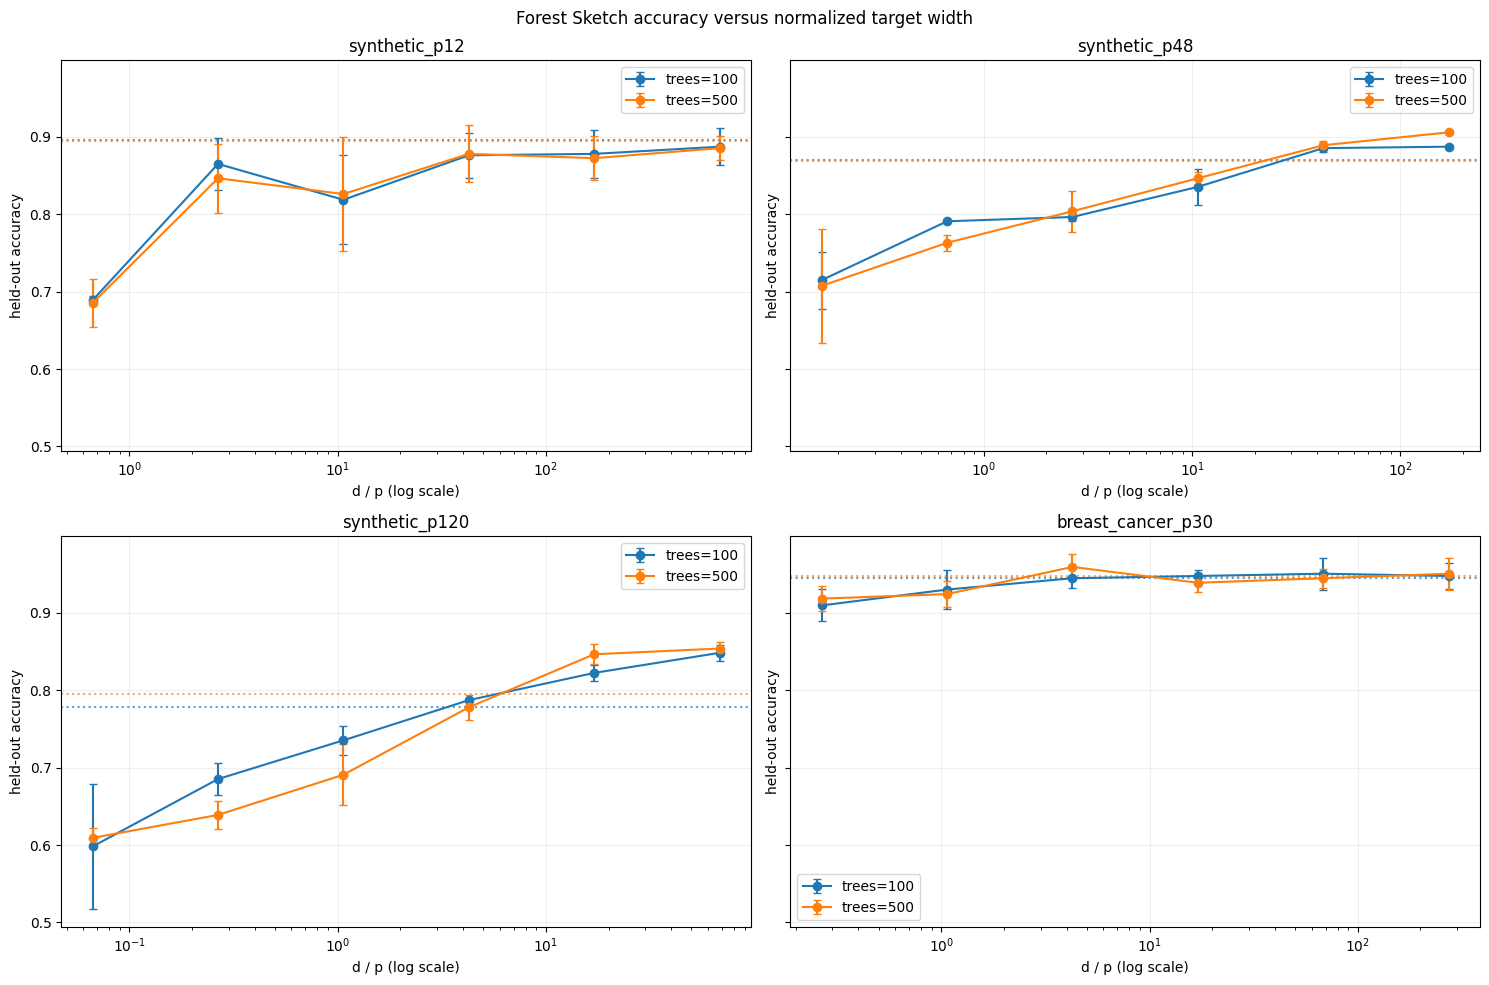

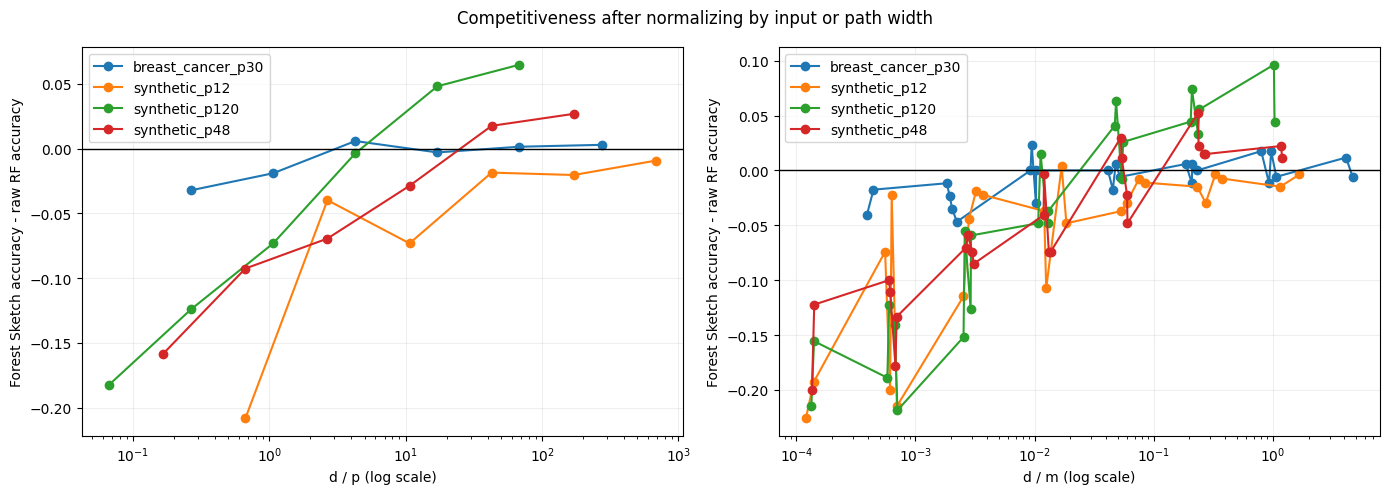

In [6]:
ok = results[results.status == "ok"].copy()
baseline = ok.groupby(["dataset", "n_estimators"], as_index=False)["raw_rf_accuracy"].mean()

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharey=True)
for ax, dataset_name in zip(axes.ravel(), DATASET_NAMES):
    subset = ok[ok.dataset == dataset_name]
    for n_estimators, group in subset.groupby("n_estimators"):
        curve = group.groupby("d", as_index=False).agg(
            d_over_p=("d_over_p", "first"),
            d_over_m=("d_over_m", "mean"),
            accuracy=("recursive_sketch_accuracy", "mean"),
            std=("recursive_sketch_accuracy", "std"),
        )
        ax.errorbar(curve.d_over_p, curve.accuracy, yerr=curve["std"].fillna(0), marker="o", capsize=3, label=f"trees={n_estimators}")
        raw_value = baseline.loc[baseline.dataset.eq(dataset_name) & baseline.n_estimators.eq(n_estimators), "raw_rf_accuracy"].iloc[0]
        ax.axhline(raw_value, linestyle=":", color=ax.lines[-1].get_color(), alpha=0.7)
    ax.set_xscale("log")
    ax.set_title(dataset_name)
    ax.set_xlabel("d / p (log scale)")
    ax.set_ylabel("held-out accuracy")
    ax.grid(alpha=0.2)
    ax.legend()
fig.suptitle("Recursive Sketch accuracy versus normalized target width")
fig.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, xcol, xlabel in zip(axes, ["d_over_p", "d_over_m"], ["d / p", "d / m"]):
    for dataset_name, group in ok.groupby("dataset"):
        curve = group.groupby(xcol, as_index=False)["accuracy_gap_to_raw"].mean().sort_values(xcol)
        ax.plot(curve[xcol], curve.accuracy_gap_to_raw, marker="o", label=dataset_name)
    ax.set_xscale("log")
    ax.axhline(0, color="black", linewidth=1)
    ax.set_xlabel(f"{xlabel} (log scale)")
    ax.set_ylabel("Recursive Sketch accuracy - raw RF accuracy")
    ax.grid(alpha=0.2)
    ax.legend()
fig.suptitle("Competitiveness after normalizing by input or path width")
fig.tight_layout()
plt.show()

## Width and cost scaling

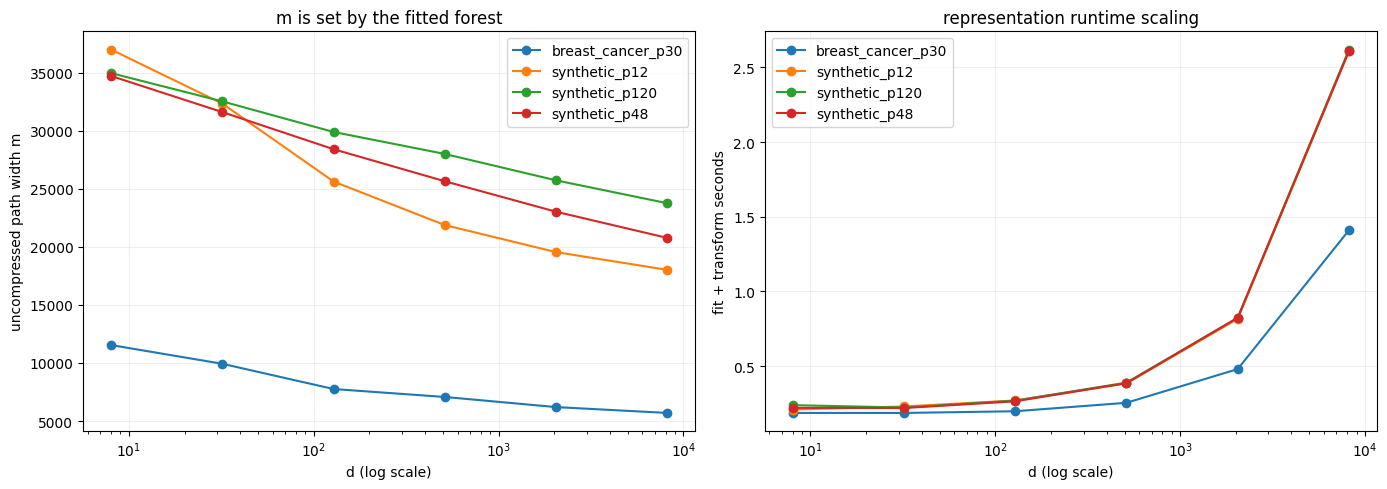

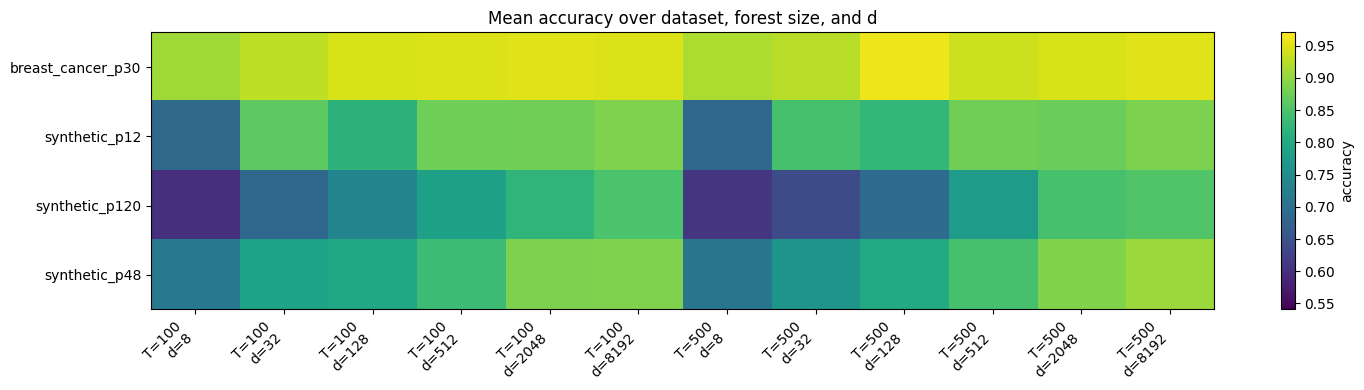

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for dataset_name, group in ok.groupby("dataset"):
    curve = group.groupby("d", as_index=False).agg(m=("m", "mean"), fit=("fit_seconds", "mean"), transform=("transform_seconds", "mean"))
    axes[0].plot(curve.d, curve.m, marker="o", label=dataset_name)
    axes[1].plot(curve["d"], curve["fit"] + curve["transform"], marker="o", label=dataset_name)
for ax in axes:
    ax.set_xscale("log")
    ax.grid(alpha=0.2)
    ax.legend()
axes[0].set_xlabel("d (log scale)")
axes[0].set_ylabel("uncompressed path width m")
axes[0].set_title("m is set by the fitted forest")
axes[1].set_xlabel("d (log scale)")
axes[1].set_ylabel("fit + transform seconds")
axes[1].set_title("representation runtime scaling")
fig.tight_layout()
plt.show()

heat = ok.pivot_table(index="dataset", columns=["n_estimators", "d"], values="recursive_sketch_accuracy", aggfunc="mean")
fig, ax = plt.subplots(figsize=(15, 4))
im = ax.imshow(heat.values, aspect="auto", cmap="viridis", vmin=ok.recursive_sketch_accuracy.min(), vmax=ok.recursive_sketch_accuracy.max())
ax.set_yticks(range(len(heat.index)), heat.index)
ax.set_xticks(range(len(heat.columns)), [f"T={t}\nd={d}" for t, d in heat.columns], rotation=45, ha="right")
ax.set_title("Mean accuracy over dataset, forest size, and d")
fig.colorbar(im, ax=ax, label="accuracy")
fig.tight_layout()
plt.show()

## Within-block analysis: does d/p survive?

The pooled correlations above mix dataset width, forest size, and projection dimension. To reduce that confounding, this section analyzes each dataset × `n_estimators` block separately. The response is the Recursive Sketch accuracy gap to the corresponding raw-forest accuracy. For each block we report Spearman's rho against `log(d/p)` and `log(d/m)` over the six dimensions and two paired seeds, without treating the small-sample p-values as confirmatory evidence.

The threshold table reports the smallest observed ratio that reaches within 0.02 accuracy points of the block's raw forest, when such a point exists. The curves retain the mean/std summaries and show separate lines for every dataset/forest-size block.

,dataset,n_estimators,n_rows,rho_log_d_over_p,rho_log_d_over_m,mean_gap
0,breast_cancer_p30,100,12,0.6071,0.5053,-0.0063
1,breast_cancer_p30,500,12,0.5571,0.4841,-0.0083
2,synthetic_p12,100,12,0.8000,0.8406,-0.0608
3,synthetic_p12,500,12,0.7376,0.8070,-0.0623
4,synthetic_p120,100,12,0.9753,0.9720,-0.0318
5,synthetic_p120,500,12,0.9470,0.9790,-0.0583
6,synthetic_p48,100,12,0.9537,0.9226,-0.0522
7,synthetic_p48,500,12,0.9753,0.9580,-0.0494


,dataset,n_estimators,min_d_over_p_within_0.02,d_at_min_d_over_p,min_d_over_m_within_0.02,d_at_min_d_over_m
0,breast_cancer_p30,100,1.0667,32.0,0.0098,32.0
1,breast_cancer_p30,500,4.2667,128.0,0.0099,128.0
2,synthetic_p12,100,170.6667,2048.0,0.3248,2048.0
3,synthetic_p12,500,42.6667,512.0,0.0145,512.0
4,synthetic_p120,100,4.2667,512.0,0.0547,512.0
5,synthetic_p120,500,4.2667,512.0,0.0110,512.0
6,synthetic_p48,100,42.6667,2048.0,0.2660,2048.0
7,synthetic_p48,500,42.6667,2048.0,0.0534,2048.0


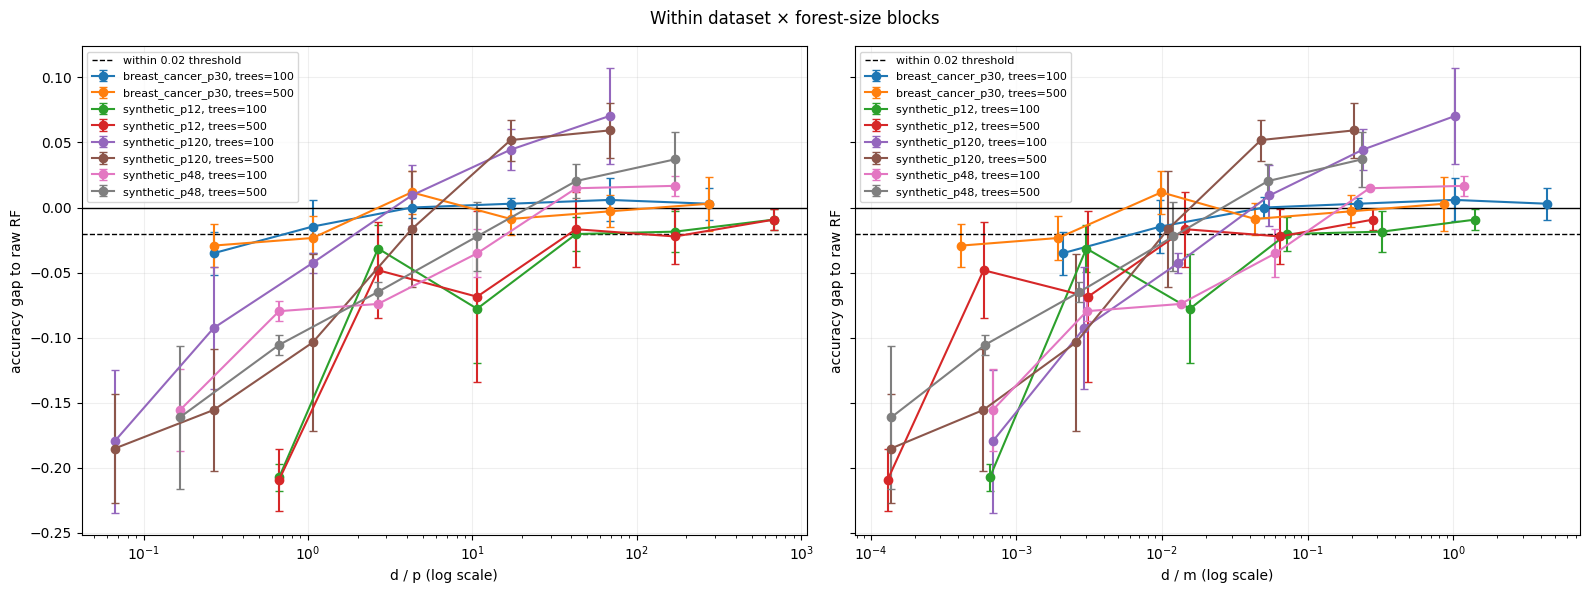

Within-block interpretation:
d/p rho is positive in 8/8 blocks; d/m rho is positive in 8/8 blocks.
The apparent pooled d/p relationship survives only as descriptive within-block evidence if its signs and threshold ratios are reasonably consistent across these blocks; two seeds and six dimensions per block are too small for a universal claim.


In [8]:
within_rows = []
threshold_rows = []

for (dataset_name, n_estimators), block in ok.groupby(["dataset", "n_estimators"]):
    block = block.copy()
    rho_dp, _ = spearmanr(np.log(block["d_over_p"]), block["accuracy_gap_to_raw"])
    rho_dm, _ = spearmanr(np.log(block["d_over_m"]), block["accuracy_gap_to_raw"])
    within_rows.append({
        "dataset": dataset_name,
        "n_estimators": n_estimators,
        "n_rows": len(block),
        "rho_log_d_over_p": rho_dp,
        "rho_log_d_over_m": rho_dm,
        "mean_gap": block["accuracy_gap_to_raw"].mean(),
    })

    by_dimension = block.groupby("d", as_index=False).agg(
        p=("p", "first"),
        m=("m", "mean"),
        d_over_p=("d_over_p", "first"),
        d_over_m=("d_over_m", "mean"),
        mean_gap=("accuracy_gap_to_raw", "mean"),
    )
    reached_dp = by_dimension[by_dimension.mean_gap >= -0.02].sort_values("d_over_p")
    reached_dm = by_dimension[by_dimension.mean_gap >= -0.02].sort_values("d_over_m")
    dp = reached_dp.iloc[0] if len(reached_dp) else None
    dm = reached_dm.iloc[0] if len(reached_dm) else None
    threshold_rows.append({
        "dataset": dataset_name,
        "n_estimators": n_estimators,
        "min_d_over_p_within_0.02": np.nan if dp is None else dp.d_over_p,
        "d_at_min_d_over_p": np.nan if dp is None else dp["d"],
        "min_d_over_m_within_0.02": np.nan if dm is None else dm.d_over_m,
        "d_at_min_d_over_m": np.nan if dm is None else dm["d"],
    })

within_summary = pd.DataFrame(within_rows)
threshold_summary = pd.DataFrame(threshold_rows)
display(within_summary.round(4))
display(threshold_summary.round(4))

fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
for (dataset_name, n_estimators), block in ok.groupby(["dataset", "n_estimators"]):
    curve = block.groupby("d", as_index=False).agg(
        d_over_p=("d_over_p", "first"),
        d_over_m=("d_over_m", "mean"),
        mean_gap=("accuracy_gap_to_raw", "mean"),
        std_gap=("accuracy_gap_to_raw", "std"),
    )
    label = f"{dataset_name}, trees={n_estimators}"
    axes[0].errorbar(curve["d_over_p"], curve["mean_gap"], yerr=curve["std_gap"].fillna(0), marker="o", capsize=3, label=label)
    axes[1].errorbar(curve["d_over_m"], curve["mean_gap"], yerr=curve["std_gap"].fillna(0), marker="o", capsize=3, label=label)
for axis, xlabel in zip(axes, ["d / p (log scale)", "d / m (log scale)"]):
    axis.set_xscale("log")
    axis.axhline(-0.02, color="black", linestyle="--", linewidth=1, label="within 0.02 threshold")
    axis.axhline(0, color="black", linewidth=1)
    axis.set_xlabel(xlabel)
    axis.set_ylabel("accuracy gap to raw RF")
    axis.grid(alpha=0.2)
    axis.legend(fontsize=8)
fig.suptitle("Within dataset × forest-size blocks")
fig.tight_layout()
plt.show()

print("Within-block interpretation:")
dp_positive = int((within_summary["rho_log_d_over_p"] > 0).sum())
dm_positive = int((within_summary["rho_log_d_over_m"] > 0).sum())
print(f"d/p rho is positive in {dp_positive}/{len(within_summary)} blocks; d/m rho is positive in {dm_positive}/{len(within_summary)} blocks.")
print("The apparent pooled d/p relationship survives only as descriptive within-block evidence if its signs and threshold ratios are reasonably consistent across these blocks; two seeds and six dimensions per block are too small for a universal claim.")

## Interpretation report

The following calculations are descriptive checks, not model-selection claims. Spearman correlations are computed over successful configuration/seed rows for accuracy against `log(d)`, `log(d/p)`, and `log(d/m)`. A useful next experiment would hold out an additional dataset and select `d` using validation data rather than reading the test curves.

In [9]:
for column in ["d", "d_over_p", "d_over_m"]:
    valid = ok[[column, "recursive_sketch_accuracy"]].dropna()
    rho, p_value = spearmanr(np.log(valid[column]), valid.recursive_sketch_accuracy)
    print(f"Spearman rho accuracy vs log({column}) = {rho:.3f}, p={p_value:.3g}")

best = (
    ok.sort_values("recursive_sketch_accuracy", ascending=False)
    .groupby(["dataset", "n_estimators"], as_index=False)
    .first()[["dataset", "n_estimators", "p", "m", "d", "d_over_p", "d_over_m", "raw_rf_accuracy", "recursive_sketch_accuracy", "accuracy_gap_to_raw"]]
)
display(best.round(4))
print("\nReport template:")
print("- Does competitiveness look more stable by p, m, d/p, d/m, or neither?")
print("- Which dataset/forest combinations are exceptions, and how wide are their seed deviations?")
print("- Limitations: only classification, one downstream learner, bounded forest settings, and exploratory test-set comparisons.")
print("- Next experiment: pre-register a validation-based d selection rule and test it on held-out datasets/task types.")
print("- Conclusion: this notebook provides exploratory evidence, not a proof.")

Spearman rho accuracy vs log(d) = 0.478, p=8.21e-07
Spearman rho accuracy vs log(d_over_p) = 0.593, p=1.94e-10
Spearman rho accuracy vs log(d_over_m) = 0.561, p=2.84e-09


,dataset,n_estimators,p,m,d,d_over_p,d_over_m,raw_rf_accuracy,recursive_sketch_accuracy,accuracy_gap_to_raw
0,breast_cancer_p30,100,30,2112,2048,68.2667,0.9697,0.9474,0.9649,0.0175
1,breast_cancer_p30,500,30,13510,128,4.2667,0.0095,0.9474,0.9708,0.0234
2,synthetic_p12,100,12,4894,8192,682.6667,1.6739,0.9074,0.9037,-0.0037
3,synthetic_p12,500,12,30304,512,42.6667,0.0169,0.9000,0.9037,0.0037
4,synthetic_p120,100,120,8012,8192,68.2667,1.0225,0.7593,0.8556,0.0963
5,synthetic_p120,500,120,40008,8192,68.2667,0.2048,0.8148,0.8593,0.0444
6,synthetic_p48,100,48,6958,8192,170.6667,1.1773,0.8667,0.8889,0.0222
7,synthetic_p48,500,48,34946,8192,170.6667,0.2344,0.8556,0.9074,0.0519



Report template:
- Does competitiveness look more stable by p, m, d/p, d/m, or neither?
- Which dataset/forest combinations are exceptions, and how wide are their seed deviations?
- Limitations: only classification, one downstream learner, bounded forest settings, and exploratory test-set comparisons.
- Next experiment: pre-register a validation-based d selection rule and test it on held-out datasets/task types.
- Conclusion: this notebook provides exploratory evidence, not a proof.
